# A04: Model Interpretability (xAI)
**Name:** Parvathi Meghanath  

Build a classification model for Loan_Status with grid search, find the top 5 features with permutation importance (20 repeats), draw partial dependence plots for them on a common Y axis, and interpret the results.

# Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gdown

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.inspection import permutation_importance

# Load the data

In [2]:
# download the dataset into the project folder (only the first time)
file_name = "train_loan_imbalanced.csv"
if not os.path.exists(file_name):
    gdown.download(id="1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W", output=file_name, quiet=False)

data = pd.read_csv(file_name)
print("Rows, columns:", data.shape)
data.head()

Rows, columns: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Data types and missing values

In [3]:
data.info()
print("\nMissing values per column:")
print(data.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB

Missing values per column:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Edu

## Cleaning the Dataset
Loan_ID is a unique code for each application, so it can't help predict anything and I remove it.
The target Loan_Status is recoded so that 1 = approved and 0 = rejected.

In [4]:
# Loan_ID carries no predictive information
data = data.drop(columns=["Loan_ID"])

# recode the target: approved (Y) -> 1, rejected (N) -> 0
data["Loan_Status"] = data["Loan_Status"].map({"Y": 1, "N": 0})

print(data["Loan_Status"].value_counts())
print("\nApproval rate:", round(data["Loan_Status"].mean(), 3))   # about 0.69, so the classes are imbalanced

Loan_Status
1    422
0    192
Name: count, dtype: int64

Approval rate: 0.687


## Splitting into Train and Test Sets

In [5]:
# predictors vs. outcome
features = data.drop(columns=["Loan_Status"])
label = data["Loan_Status"]

# 80/20 split; stratify keeps the approval rate the same in train and test
Xtr, Xte, ytr, yte = train_test_split(features, label, test_size=0.2,
                                      stratify=label, random_state=1)

# check the size of each part
print("Training shape:", Xtr.shape)
print("Testing shape:", Xte.shape)

# check that the class balance is kept in both parts
print("\nTraining class distribution:")
print(ytr.value_counts())

print("\nTesting class distribution:")
print(yte.value_counts())

Training shape: (491, 11)
Testing shape: (123, 11)

Training class distribution:
Loan_Status
1    337
0    154
Name: count, dtype: int64

Testing class distribution:
Loan_Status
1    85
0    38
Name: count, dtype: int64


## Preprocessing
Missing numeric values are filled with the median, and missing categories with the most
common level. Categorical columns are then one-hot encoded. Because all of this happens
inside a pipeline, it is learned only from the training data, so nothing leaks from the test set.

In [6]:
numeric = Xtr.select_dtypes(include="number").columns.tolist()
categorical = [c for c in Xtr.columns if c not in numeric]
print("Numeric:", numeric)
print("Categorical:", categorical)

transformer = ColumnTransformer([
    ("nums", SimpleImputer(strategy="median"), numeric),
    ("cats", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("dummies", OneHotEncoder(handle_unknown="ignore"))]), categorical)
])

Numeric: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Categorical: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


## Random Forest + Grid Search

In [7]:
rf_pipe = Pipeline([("transform", transformer),
                    ("forest", RandomForestClassifier(random_state=1))])

grid_values = {
    "forest__n_estimators": [150, 300],
    "forest__max_depth": [4, 8, None],
    "forest__min_samples_leaf": [1, 5],
    "forest__class_weight": [None, "balanced"]
}

tuner = GridSearchCV(rf_pipe, grid_values, scoring="roc_auc",
                     cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
                     n_jobs=-1)
tuner.fit(Xtr, ytr)

forest_model = tuner.best_estimator_
print("Best settings:", tuner.best_params_)
print("Cross-validated AUC:", round(tuner.best_score_, 3))

Best settings: {'forest__class_weight': 'balanced', 'forest__max_depth': 4, 'forest__min_samples_leaf': 5, 'forest__n_estimators': 150}
Cross-validated AUC: 0.753


# Test set evaluation

In [8]:
test_pred = forest_model.predict(Xte)
test_prob = forest_model.predict_proba(Xte)[:, 1]

print("Test AUC:", round(roc_auc_score(yte, test_prob), 3))
print("\nConfusion matrix:")
print(confusion_matrix(yte, test_pred))
print("\nClassification report:")
print(classification_report(yte, test_pred))

Test AUC: 0.765

Confusion matrix:
[[21 17]
 [18 67]]

Classification report:
              precision    recall  f1-score   support

           0       0.54      0.55      0.55        38
           1       0.80      0.79      0.79        85

    accuracy                           0.72       123
   macro avg       0.67      0.67      0.67       123
weighted avg       0.72      0.72      0.72       123



The grid search tried 24 Random Forest settings (number of trees, depth, minimum leaf size,
and whether to up-weight the rejected class), each scored with 5-fold cross-validation.
I used ROC AUC instead of accuracy because about 69% of loans are approved, so a model
that approves everyone would still look accurate.

# Permutation importance (Top 5 features, 20 repeats) and boxplot

              feature  mean_drop  std_drop
0      Credit_History     0.2684    0.0434
1       Property_Area     0.0246    0.0325
2             Married     0.0154    0.0164
3          LoanAmount     0.0091    0.0097
4    Loan_Amount_Term     0.0036    0.0022
5          Dependents     0.0036    0.0057
6     ApplicantIncome     0.0028    0.0110
7       Self_Employed     0.0013    0.0013
8   CoapplicantIncome     0.0005    0.0129
9              Gender    -0.0018    0.0042
10          Education    -0.0019    0.0048

Top 5 features: ['Credit_History', 'Property_Area', 'Married', 'LoanAmount', 'Loan_Amount_Term']


C:\Users\parva\AppData\Local\Temp\ipykernel_24080\4177599326.py:18: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(imp.importances[col_pos].T, vert=False, tick_labels=top_feats)


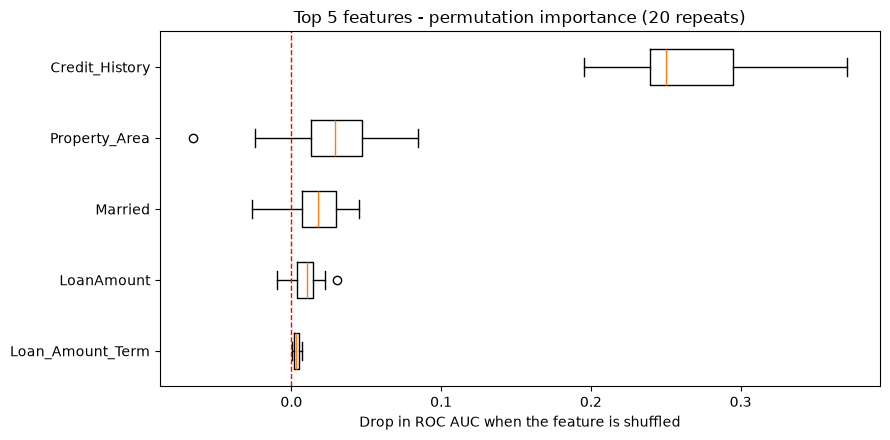

In [9]:
# The pipeline receives the raw Xte, so each ORIGINAL column is shuffled.
# The results line up with Xte.columns (not with one-hot encoded names).
imp = permutation_importance(forest_model, Xte, yte, n_repeats=20,
                             scoring="roc_auc", random_state=1, n_jobs=-1)

imp_df = (pd.DataFrame({"feature": Xte.columns,
                        "mean_drop": imp.importances_mean,
                        "std_drop": imp.importances_std})
          .sort_values("mean_drop", ascending=False)
          .reset_index(drop=True))
print(imp_df.round(4))

top_feats = imp_df["feature"].head(5).tolist()
col_pos = [Xte.columns.get_loc(f) for f in top_feats]
print("\nTop 5 features:", top_feats)

plt.figure(figsize=(9, 4.5))
plt.boxplot(imp.importances[col_pos].T, vert=False, tick_labels=top_feats)
plt.gca().invert_yaxis()                       # most important feature on top
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Drop in ROC AUC when the feature is shuffled")
plt.title("Top 5 features - permutation importance (20 repeats)")
plt.tight_layout()
plt.show()

## Interpretation of Permutation Importance
* The X-axis shows the drop in test AUC when I shuffle a feature, and each box shows the spread across the 20 shuffles.
* Credit_History is by far the most important feature, dropping the AUC by about 0.27, about 11 times more than any other feature.
* Property_Area (0.025) and Married (0.015) come next, but their boxes cross 0, so their importance isn't very stable.
* LoanAmount (0.009) and Loan_Amount_Term (0.004) barely matter, although Loan_Amount_Term's narrow box shows its small effect is consistent.
* I was surprised that ApplicantIncome (0.003) and CoapplicantIncome (0.0005) were close to zero, since I expected income to matter a lot for loans.

## Partial Dependence Plots (Top 5)
* For each feature, I set every applicant to the same value and averaged the model's predicted approval probability, so I can see how the prediction changes with that feature.

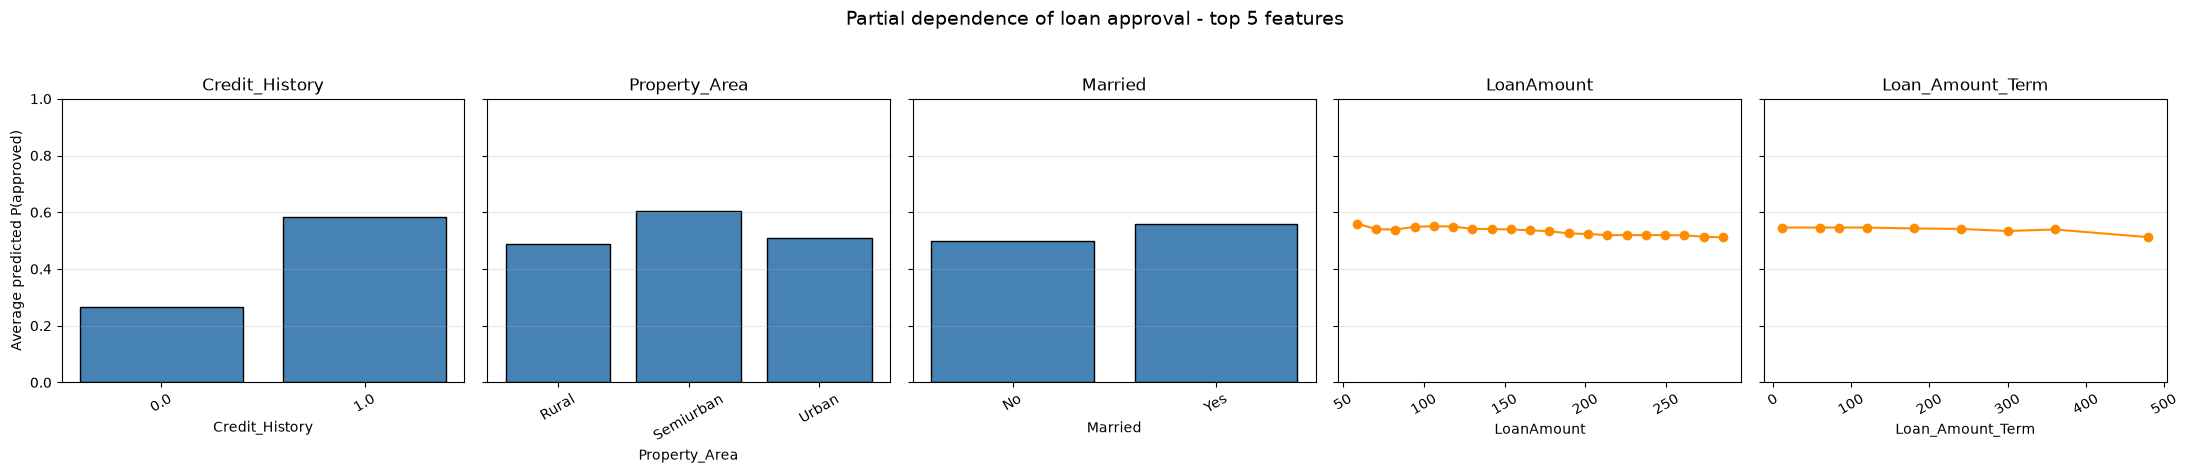

In [10]:
# PDP data: fill NaNs the same way the pipeline does
Xpd = Xtr.copy()
Xpd[numeric] = Xpd[numeric].fillna(Xtr[numeric].median())
Xpd[categorical] = Xpd[categorical].fillna(Xtr[categorical].mode().iloc[0])

def make_grid(col, n_points=20):
    """Values at which to evaluate the model for one feature (n_points = num_grid_points)."""
    values = Xpd[col]
    if col in categorical or values.nunique() <= 10:      # categories / few levels -> use each level
        return np.sort(values.unique())
    lo, hi = np.percentile(values, [5, 95])                # continuous -> evenly spaced points
    return np.linspace(lo, hi, n_points)

# set the feature to each grid value for EVERY applicant,
# predict with the full pipeline, and average the approval probability
pdp_results = {}
for feat in top_feats:
    grid_pts = make_grid(feat)
    avg_probs = []
    for value in grid_pts:
        X_temp = Xpd.copy()
        X_temp[feat] = value
        avg_probs.append(forest_model.predict_proba(X_temp)[:, 1].mean())
    pdp_results[feat] = (grid_pts, np.array(avg_probs))

# plot: bars for categories/binary features, lines for continuous ones
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5), sharey=True)
for ax, feat in zip(axes, top_feats):
    grid_pts, avg_probs = pdp_results[feat]
    if feat in categorical or len(grid_pts) <= 2:
        ax.bar([str(g) for g in grid_pts], avg_probs, color="steelblue", edgecolor="black")
    else:
        ax.plot(grid_pts, avg_probs, marker="o", color="darkorange")
    ax.set_title(feat)
    ax.set_xlabel(feat)
    ax.set_ylim(0, 1)                       # identical Y axis on all five plots
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, axis="y", alpha=0.3)

axes[0].set_ylabel("Average predicted P(approved)")
fig.suptitle("Partial dependence of loan approval - top 5 features", y=1.04, fontsize=14)
plt.tight_layout()
plt.show()

# PDP values

In [11]:
for feat, (grid_pts, avg_probs) in pdp_results.items():
    print(f"{feat}: min {avg_probs.min():.3f}, max {avg_probs.max():.3f}, "
          f"change {avg_probs.max() - avg_probs.min():.3f}")
    if len(grid_pts) <= 5:
        print("   ", {str(g): round(float(p), 3) for g, p in zip(grid_pts, avg_probs)})

Credit_History: min 0.265, max 0.585, change 0.320
    {'0.0': 0.265, '1.0': 0.585}
Property_Area: min 0.489, max 0.604, change 0.116
    {'Rural': 0.489, 'Semiurban': 0.604, 'Urban': 0.511}
Married: min 0.497, max 0.558, change 0.061
    {'No': 0.497, 'Yes': 0.558}
LoanAmount: min 0.511, max 0.560, change 0.049
Loan_Amount_Term: min 0.512, max 0.546, change 0.034


## Interpretation of Partial Dependence Plots
* The X-axis is the value of each feature, and the Y-axis is the average predicted probability of approval, on the same 0 to 1 scale in all five plots.
* Credit_History has the biggest effect: approval jumps from about 0.27 without a good credit history to about 0.59 with one.
* Semiurban applicants have the highest approval (about 0.60) compared with Rural (0.49) and Urban (0.51), which surprised me.
* Married applicants are slightly more likely to be approved (about 0.56 vs. 0.50), while larger loans and longer terms lower approval only a little (about 0.56 to 0.51).
* All the probabilities sit below the real approval rate of 0.69 because the model used class_weight='balanced', which makes it more cautious about approving.